# Stochastic Simulation

This chapter covers
- the basics of stochastic simulation
- optimization for performance

Let's start by importing libraries we will need:

In [29]:
# %pip install numpy scipy numba line_profiler

# multiprocessing & progress
import joblib
import tqdm

import numpy as np
import scipy.stats as st
import numba

# plotting
import matplotlib.pyplot as plt
figsize = (5,4)

# profiler
%load_ext line_profiler

The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


## Sampling traces from a CRN

Assume we are given a CRN and are interested to generate traces for this CRN.
This is also called sampling its CME exactly: if wwe would be repeating this process we would get closer and closer to the distribution of the CME.

Let us study how this can be done at the hand of our well known running example:

<div style="border-left:4px solid #4f7942; padding:1em 1.6em; margin:1.8em 0; border-radius:0 5px 5px 0;">

**Example: gene expression propensities**

Given a state $(m, p)$ for our gene expression system, we can write propensities as:

\begin{align}
\begin{array}{ll}
\text{reaction }r_i & \text{propensity } a_i \\
m \rightarrow m+1,\;\;\;\; & \beta_m \\[0.3em]
m \rightarrow m-1, \;\;\;\; & m\\[0.3em]
p \rightarrow p+1, \;\;\;\; & \beta_p m \\[0.3em]
p \rightarrow p-1, \;\;\;\; & \gamma p\enspace.
\end{array}
\end{align}


</div>

## Naive algorithm

For each reaction $r_i$, with $1 \leq i \leq k$, and propensity $a_i$ for reaction $r_i$, the time until its next occurrence, given no other reaction fires first, is

$$T_i \sim \text{Exp}(a_i).$$

Since the processes are independent, the first reaction to fire is

$$j = \arg\min_i T_i.$$

We apply the reaction to the current state and increment the time by $T_j$.
All other reaction times $T_i, i \neq j$ can be thrown away and be considered to not happen.
This is correct since the CRN is memoryless.

The process is repeated until some maximum simulation time or no reactions can fire anymore.

This scheme immediately gives a naive algorithm that **exactly samples the Chemical Master Equation (CME)**.
However, the **cost of $k$ exponential draws per step** can be improved as we will see in the next section.


## The Gillespie algorithm

Gillespie introduced and proved a simple and efficient algorithm that exactly samples the probability distribution described by the master equation; see [(Gillespie; Journal of Computational Physics, 1976)](https://doi.org/10.1016/0021-9991(76)90041-3) and [(Gillespie; The Journal of Physical Chemistry, 1977)](http://doi.org/10.1021/j100540a008).
We discuss this algorithm and a Python implementation in the following.



The idea of this improved algorithm is to split the question which reaction will be the first one and when it will happen into two separate questions.

####  Transition probabilities
The probability that the state change that happens because of reaction $j$ is proportional to $a_j$.
State changes with high propensities are more likely to occur.
Thus, choosing which of the $k$ state changes happens in $\Delta t$ can be determined by drawing an integer $j \in [1,k]$ where the probability of drawing $j$ is

\begin{align}
\frac{a_j}{\sum_i a_i}\enspace.
\end{align}


####  Transition times
Now, how do we determine how long the state change took?
From before, we know that

$T_i(x) \sim \text{Exp}(a_i)$$

The probability density function $p_i$ for the stochastic variable $T_i$ thus is

\begin{align}
p_i(t) = a_i\, \mathrm{e}^{-a_i t}\enspace,
\end{align}

for $t \geq 0$, and $0$ otherwise.

The time $T(x)$ until the first reaction occurs in state $x$ is given by

$$T(x) = \min_{i} T_i(x).$$

One can show that

$$T(x) \sim \text{Exp}\left(\sum_i a_i\right).$$


### The algorithm
So, we know how to choose a state change and we also know how long it takes.
The Gillespie algorithm then proceeds as follows.

- Input: initial state $x$.
- Loop until done:
  - Calculate the propensity for each reaction depending on the current state $x$.
  - Compute how much time $\Delta$ the reaction will take by drawing out of an exponential distribution rate $\sum_i a_i$.
  - Compute which reaction will fire by drawing a sample out of the discrete distribution where $P_i = \left.a_i\middle/\left(\sum_i a_i\right)\right.$.
  - Increment time by $\Delta$ and update the states according to the reaction that fires.


## Implementing the Gillespie algorithm

To code up the Gillespie simulation, we first encode state updates as vectors, here for the running example:

In [ ]:
from typing import TypedDict


class CRN(TypedDict):
    species: list[str]
    r_vec: np.ndarray
    state_update_vec: np.ndarray
    rate_constants: np.ndarray


species = ["mRNA", "protein"]

r_vec = np.array([
    [0, 0],  # DNA -> DNA + mRNA
    [1, 0],  # mRNA -> 0
    [1, 0],  # mRNA -> mRNA + protein
    [0, 1],  # protein -> 0
    ], dtype=int)

state_update_vec: np.ndarray = np.array(
    [
        [ 1,  0],  # DNA -> DNA + mRNA
        [-1,  0],  # mRNA -> 0
        [ 0,  1],  # mRNA -> mRNA + protein
        [ 0, -1],  # protein -> 0
    ],
    dtype=int,
)

rate_constants = np.array([0.5, 0.1, 0.2, 0.05], dtype=float)

example_crn: CRN = {
    "species": species,
    "r_vec": r_vec,
    "state_update_vec": state_update_vec,
    "rate_constants": rate_constants,
}


Next, propensities for the current state are returned via:

In [31]:
def update_propensity(
        propensities: np.ndarray,
        state: np.ndarray,
        r_vec: np.ndarray,
        rate_constants: np.ndarray) -> None:
    """Update the propensities for each reaction based on the current state.
    
    Attention: assumes that r_vec only contains 0, 1, and 2

    Parameters
    ----------
    propensities : np.ndarray
        Array to store the propensities for each reaction.
    state : np.ndarray
        Current state of the system (number of molecules of each species).
    r_vec : np.ndarray
        Reactant vector indicating how many molecules of each species are consumed by each reaction.
    rate_constants : np.ndarray
        Rate constants for each reaction.
    """
    propensities[:] = rate_constants * (
        np.where(r_vec >= 1, state, 1) * np.where(r_vec == 2, state - 1, 1)
    ).prod(axis=1)


### Time until reaction

First, to get the time until a reaction occurs, we sample a random number from an exponential distribution with rate parameter $\left(\sum_i a_i\right)$, i.e., mean $\left(\sum_i a_i\right)^{-1}$.
This can be done using the `np.random.exponential()` function.  

### Determine which reaction occurs

Next, we have to select which reaction will take place.  This amounts to drawing a sample over the discrete distribution where $P_i = a_i\left(\sum_i a_i\right)^{-1}$.
This can be done using `scipy.stats.rv_discrete`, which allows specification of an arbitrary discrete distribution.
We then use `rvs()` on this object to sample the distribution once.

In [32]:
def sample_discrete_scipy(probs: np.ndarray) -> int:
    """Randomly sample an index with probability given by probs.
    
    Parameters:
    ----------
    probs: np.ndarray
        An array of probabilities for each index. The probabilities must sum to 1."""
    return st.rv_discrete(values=(range(len(probs)), probs)).rvs()

This is a nice one-liner, but is it fast? There may be significant overhead in setting up the `scipy.stats` discrete random variable object to sample from each time. Remember, we can't just do this once because the array `probs` changes with each step in the SSA because the propensities change. We will therefore write a less elegant, but maybe faster way of doing it.  

Another way to sample the discrete distribution is to generate a uniformly distributed random number $q \sim \text{Uniform}(0,1)$ within bounds $0$ and $1$,
and return the value $j$ such that

\begin{align}
\sum_{i=0}^{j-1} p_i < q < \sum_{i=0}^{j}p_i.
\end{align}

We'll code this up.

In [33]:
def sample_discrete(probs: np.ndarray) -> int:
    """Randomly sample an index with probability given by probs."""
    # Generate random number
    q: float = np.random.rand()
    
    # Find index
    i: int = 0
    p_sum: float = 0.0
    while p_sum < q:
        p_sum += probs[i]
        i += 1
    return i - 1

Now let's compare the speeds using the `%timeit` function. This is a useful tool to help diagnose slow spots in your code.

In [36]:
# Make dummy probs
probs: np.ndarray = np.array([0.1, 0.3, 0.4, 0.05, 0.15])

print('Result from scipy.stats:')
%timeit sample_discrete_scipy(probs)

print('\nResult from plain Python method:')
%timeit sample_discrete(probs)

Result from scipy.stats:
172 μs ± 4.5 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)

Result from plain Python method:
513 ns ± 17.1 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


The Python method is a couple of orders of magnitude faster - we will thus use it.

We next code a function that returns the two random draws we need for the Gillespie step.

In [ ]:
def gillespie_draw(
        state: np.ndarray,
        propensities: np.ndarray,
        crn: dict,
        ) -> tuple[int, float]:
    """
    Draws a reaction and the time it took to do that reaction.
        
    Returns
    -------
    rxn : int
        Index of reaction that occurred.
    time : float
        Time it took for the reaction to occur.
    """
    # Compute propensities
    update_propensity(
        propensities,
        state,
        crn["r_vec"],
        crn["rate_constants"])
    
    # Sum of propensities
    props_sum = propensities.sum()
    
    # sample time step
    delta = np.random.exponential(1.0 / props_sum)
    
    # Compute discrete probabilities of each reaction
    rxn_probs = propensities / props_sum
    
    # Draw reaction from this distribution
    rxn = sample_discrete(rxn_probs)
    
    return rxn, delta

## SSA time stepping

Now we are ready to write our main SSA loop.  We will only keep the counts at pre-specified time points. This saves on RAM, and we really only care about the values at given time points anyhow.

Note that this function is generic. All we need to specify our system is the following.

* A function to compute the propensities
* How the updates for a given reaction are made
* Initial population

Additionally, we specify necessary parameters, an initial condition, and the time points at which we want to store our samples. So, providing the propensity function and update are analogous to providing the time derivatives when using `scipy.integrate.odeint()`.

In [ ]:
def gillespie_ssa(
        propensity_func,
        update,
        population_0,
        time_points,
        ) -> np.ndarray:
    """
    Uses the Gillespie stochastic simulation algorithm to sample
    from probability distribution of particle counts over time.
    
    Parameters
    ----------
    propensity_func : function
        Function of the form f(params, t, population) that takes the current
        population of particle counts and return an array of propensities
        for each reaction.
    update : ndarray, shape (num_reactions, num_chemical_species)
        Entry i, j gives the change in particle counts of species j
        for chemical reaction i.
    population_0 : array_like, shape (num_chemical_species)
        Array of initial populations of all chemical species.
    time_points : array_like, shape (num_time_points,)
        Array of points in time for which to sample the probability
        distribution.    

    Returns
    -------
    sample : ndarray, shape (num_time_points, num_chemical_species)
        Entry i, j is the count of chemical species j at time
        time_points[i].
    """

    # Initialize output
    pop_out = np.empty((len(time_points), update.shape[1]), dtype=int)

    # Initialize and perform simulation
    i_time = 1
    i = 0
    t = time_points[0]  # set time to initial time
    population = population_0.copy()
    pop_out[0, :] = population  # output the first population counts
    propensities = np.zeros(update.shape[0])
    
    while i < len(time_points):
        while t < time_points[i_time]:
            # draw the event and time step
            event, dt = gillespie_draw(
                propensity_func, propensities, population, t, args
            )

            # Update the population
            population_previous = population.copy()
            population += update[event, :]

            # Increment time
            t += dt

        # Update the index
        i = np.sum(time_points <= t)

        # Update the population
        pop_out[i_time : min(i, len(time_points))] = population_previous

        # Increment index
        i_time = i

    return pop_out

## Running and parsing results

We can now run a set of SSA simulations and plot the results.  We will run 100 trajectories and store them, using $\beta_p = \beta_m = 10$ and $\gamma = 0.4$. We will also use the nifty package `tqdm` to give a progress bar so we know how long it is taking.

In [9]:
# Specify parameters for calculation
args = (10.0, 10.0, 0.4)                    # the rate constants
time_points = np.linspace(0, 50, 101)       # output times
population_0 = np.array([0, 0], dtype=int)  # initial counts
n_trajectories = 100                        # how many trajectories we want

# Seed random number generator for reproducibility
np.random.seed(42)

# Initialize output array
samples = np.empty((n_trajectories, len(time_points), 2), dtype=int)

# Run the calculations
for i in tqdm.tqdm(range(n_trajectories)):
    samples[i, :, :] = gillespie_ssa(
        simple_propensity, simple_update, population_0, time_points, args=args
    )

100%|██████████| 100/100 [00:06<00:00, 16.38it/s]


We now have our samples, so we can plot the trajectories. For visualization, we will plot every trajectory as a thin blue line, and then the average of the trajectories as a thick orange line.

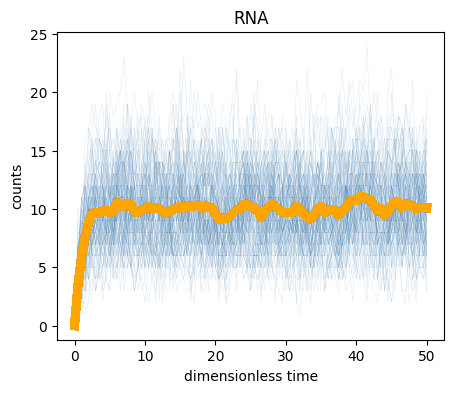

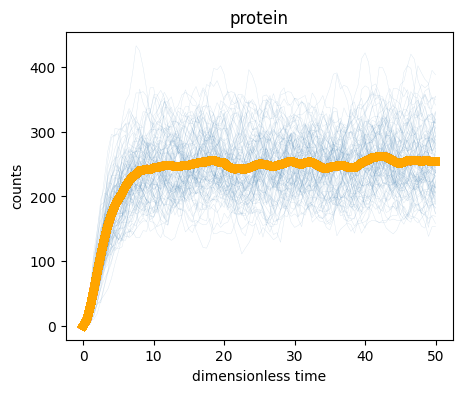

In [10]:
# Plot trajectories and mean
for i, name in enumerate(["RNA", "protein"]):
    plt.figure(figsize=figsize)
    plt.xlabel("dimensionless time")
    plt.ylabel("counts")
    plt.title(name)

    for x in samples[:, :, i]:
        plt.plot(
            time_points,
            x,
            lw=0.3,
            alpha=0.2,
            color="steelblue",
        )
        plt.plot(
            time_points,
            samples[:, :, i].mean(axis=0),
            lw=6,
            color="orange",
        )

We can also compute the steady state properties by considering the end of the simulation.  The last 50 time points are at steady state, so we will average over them.

In [11]:
print("mRNA mean copy number =", samples[:, -50:, 0].mean())
print("protein mean copy number =", samples[:, -50:, 1].mean())

print("\nmRNA variance =", samples[:, -50:, 0].std() ** 2)
print("protein variance =", samples[:, -50:, 1].std() ** 2)

print("\nmRNA CV =", samples[:, -50:, 0].std() / samples[:, -50:, 0].mean())
print(
    "protein CV =", samples[:, -50:, 1].std() / samples[:, -50:, 1].mean()
)

mRNA mean copy number = 10.0748
protein mean copy number = 251.6994

mRNA variance = 10.26200496
protein variance = 2145.33703964

mRNA CV = 0.317965262817717
protein CV = 0.18402023679851773


### Steady state
Finally, we can compute the steady state probability distributions.
To plot them, we plot the empirical probability density function (EPDF) from the sampling.

#### Inline Q:
Which steady state would you expect for mRNA and proteins from the ODE?
Let's check if they match.

A Poisson distribution with this mean has been overlayed for mRNA.

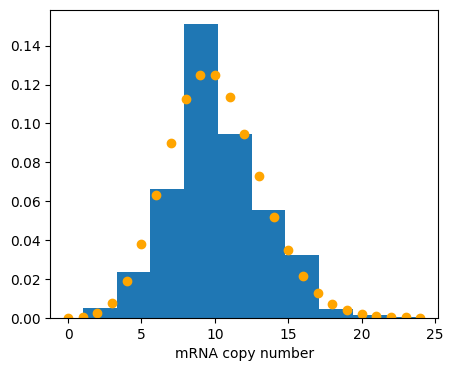

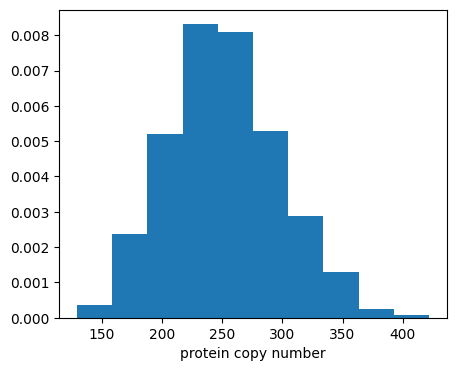

In [12]:
def epdf(vals, xlabel):
    plt.xlabel(xlabel)
    plt.hist(vals, density=True)

# mRNA ECDF
plt.figure(figsize=figsize)
epdf(
    samples[:, -50:, 0].flatten(),
    xlabel="mRNA copy number",
)

# Theoretial mRNA pdf/pmf (Poisson)
x = np.arange(25)
plt.plot(
    x,
    st.poisson.pmf(x, args[0]),
    'o',
    color="orange"
)

# protein ECDF
plt.figure(figsize=figsize)
epdf(
    samples[:, -50:, 1].flatten(),
    xlabel="protein copy number",
)


As we expect, the mRNA copy number matches the Poisson distribution. We also managed to get a distribution for the protein copy number that we could plot. 

You now have the basic tools for doing Gillespie simulations. You just need to code the propensity function and the update, and you're on your way! (Note, though, that this only works for Gillespie simulations where the states are defined by particle counts, which should suffice for this course.)

## Increasing speed

In this section of the tutorial, we briefly discuss some strategies for boosting the speed of your Gillespie simulation.

A significant speed boost is achieved by [just-in-time compliation](https://en.wikipedia.org/wiki/Just-in-time_compilation) using [Numba](http://numba.pydata.org). To utilize this feature, you need to just-in-time compile (JIT) your propensity function. You can insist that everything is compiled (and therefore skip the comparably slow Python interpreter) by using the `@numba.njit` decorator. In many cases, like in this one for simple gene expression, that is all you have to do.

In [13]:
@numba.njit
def simple_propensity(propensities, population, t, beta_m, beta_p, gamma):
    """Updates an array of propensities given a set of parameters
    and an array of populations.
    """
    # Unpack population
    m, p = population

    # Update propensities
    propensities[0] = beta_m  # Make mRNA transcript
    propensities[1] = m  # Degrade mRNA
    propensities[2] = beta_p * m  # Make protein
    propensities[3] = gamma * p  # Degrade protein

Let us try it out and get 1000 samples.

In [14]:
n_trajectories = 1000

samples = np.empty((n_trajectories, len(time_points), 2), dtype=int)

for i in tqdm.tqdm(range(n_trajectories)):
    samples[i, :, :] = gillespie_ssa(
        simple_propensity,
        simple_update,
        population_0,
        time_points,
        args=args
    )

100%|██████████| 1000/1000 [00:35<00:00, 28.54it/s]


We now have 1000 trajectories, and we can again make the plots as we did before. With so many trajectories, though, we should not show them all, since there would be too many glyphs on the plot. We therefore thin out the samples for plotting, taking only every 100th trajectory.

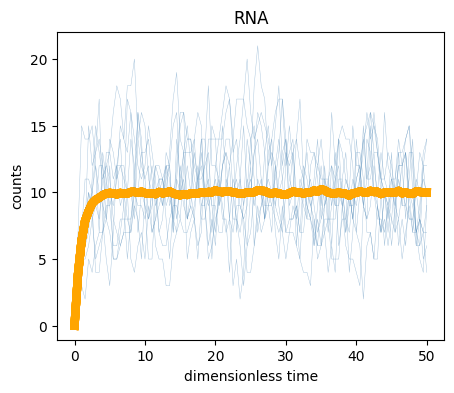

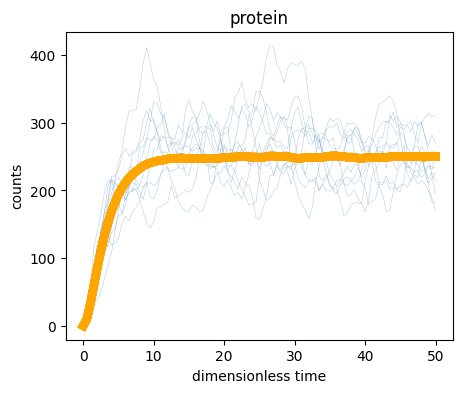

In [15]:
# Plot trajectories and mean
for i, name in enumerate(["RNA", "protein"]):
    plt.figure(figsize=figsize)
    plt.xlabel("dimensionless time")
    plt.ylabel("counts")
    plt.title(name)

    for x in samples[::100, :, i]:
        plt.plot(
            time_points,
            x,
            lw=0.3,
            alpha=0.5,
            color="steelblue",
        )
        plt.plot(
            time_points,
            samples[:, :, i].mean(axis=0),
            lw=6,
            color="orange",
        )

### Computing the Propensity

An obvious speed improvement can be made by only recalculating the propensity for copy numbers we have not visited.
For example, for simple gene expression, we do not need to recompute the propensity for mRNA decay if the previous move was a protein decay. The propensity for mRNA decay is the same it was at the previous step. Gibson and Bruck developed the [next reaction method](http://doi.org/10.1021/jp993732q), which makes these improvements, among others, and can result in significant speed-up for complicated sets of reactions. Instead of wading into the algorithmic details, we will instead investigate how we can speed up our implementation of the direct Gillespie algorithm.

### Let's compare

We will first remake the non-JITted version of the propensity function to test its speed.

In [16]:
def simple_propensity(propensities, population, t, beta_m, beta_p, gamma):
    """Updates an array of propensities given a set of parameters
    and an array of populations.
    """
    # Unpack population
    m, p = population

    # Update propensities
    propensities[0] = beta_m  # Make mRNA transcript
    propensities[1] = m  # Degrade mRNA
    propensities[2] = beta_p * m  # Make protein
    propensities[3] = gamma * p  # Degrade protein

Let's do some profiling to see what took so long.  We will use the magic function `%lprun` to profile runs of SSAs.  The output has line wrapping, so it is kind of hard to read in a Jupyter notebook, unfortunately.
We use the `-f` flag to specify which function to profile linewise.

In [17]:
%lprun -T lp_results.txt -f gillespie_ssa gillespie_ssa(\
        simple_propensity, simple_update, population_0, time_points, args)


*** Profile printout saved to text file 'lp_results.txt'.


Timer unit: 1e-09 s

Total time: 0.124621 s
File: /var/folders/hd/g16tvgfd6pddg2qvrkrypykr0000gp/T/ipykernel_43604/870969235.py
Function: gillespie_ssa at line 1

Line #      Hits         Time  Per Hit   % Time  Line Contents
     1                                           def gillespie_ssa(propensity_func, update, population_0, time_points, args=()):
     2                                               """
     3                                               Uses the Gillespie stochastic simulation algorithm to sample
     4                                               from probability distribution of particle counts over time.
     5                                           
     6                                               Parameters
     7                                               ----------
     8                                               propensity_func : function
     9                                                   Function of the form f(params, t, population) 

We see that 80% of the time is spent doing draws.  Nothing else is really worth looking at.  Let's see how we can improve our draw speed.

In [18]:
propensities = np.ones(4)

%lprun -T lp_results.txt -f gillespie_draw \
        [gillespie_draw(simple_propensity, propensities, population_0, 0, args) \
            for _ in range(10000)]


*** Profile printout saved to text file 'lp_results.txt'.


Timer unit: 1e-09 s

Total time: 0.0961 s
File: /var/folders/hd/g16tvgfd6pddg2qvrkrypykr0000gp/T/ipykernel_43604/267624423.py
Function: gillespie_draw at line 1

Line #      Hits         Time  Per Hit   % Time  Line Contents
     1                                           def gillespie_draw(propensity_func, propensities, population, t, args=()):
     2                                               """
     3                                               Draws a reaction and the time it took to do that reaction.
     4                                           
     5                                               Parameters
     6                                               ----------
     7                                               propensity_func : function
     8                                                   Function with call signature propensity_func(population, t, *args)
     9                                                   used for computing propensities. This funct

The propensity function is taking the most time. We will focus on improving that.

### Speed boost by JIT compilation with Numba

As we have seen [Numba](https://numba.pydata.org) is a package that does LLVM optimized just-in-time compilation of Python code.  The speed-ups can be substantial.  We will use `numba` to compile the parts of the code that we can.  For many functions, we just need to decorate the function with

    @numba.jit()

and that is it.  If possible, we can use the `nopython=True` keyword argument to get more speed because the compiler can assume that all of the code is JIT-able. Note that using

    @numba.njit
    
is equivalent to using `@numba.jit(nopython=True)`.

In [19]:
@numba.njit
def simple_propensity_numba(
    propensities, population, t, beta_m, beta_p, gamma
):
    """Updates an array of propensities given a set of parameters
    and an array of populations.
    """
    # Unpack population
    m, p = population

    # Update propensities
    propensities[0] = beta_m  # Make mRNA transcript
    propensities[1] = m  # Degrade mRNA
    propensities[2] = beta_p * m  # Make protein
    propensities[3] = gamma * p  # Degrade protein

    
# Check speeds
print('Old propensity function:')
%timeit simple_propensity(propensities, population_0, 0, *args)

print('\nNumba\'d propensity function:')
%timeit simple_propensity_numba(propensities, population_0, 0, *args)

Old propensity function:
2.28 μs ± 94.2 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)

Numba'd propensity function:
290 ns ± 3.65 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


We got some speed up! Nice! 

Now, we also saw that the sums and division of arrays are slow. Let's optimize the sum operation using `numba`.

In [20]:
@numba.njit
def sum_numba(ar):
    return ar.sum()


# Make dummy array for testing
ar = np.array([0.3, 0.4, 0.3, 0.2, 0.15])

print('\nNumPy sum:')
%timeit ar.sum()

print('\nNumba sum:')
%timeit sum_numba(ar)


NumPy sum:
630 ns ± 14.4 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)

Numba sum:
125 ns ± 2.49 ns per loop (mean ± std. dev. of 7 runs, 10,000,000 loops each)


We get another speed boost, though we should note that this speed boost in the sum is due to `numba` optimizing sums of a certain size.  For sums over large numbers of entries, `numba`'s performance will not exceed NumPy's by much at all.

Finally, we will speed up the sampling of the discrete distribution.  We will do this in two ways.  First, we notice that the division operation on the propensities took a fair amount of time when we profiled the code.  We do not need it; we can instead sample from an unnormalized discrete distribution.  Secondly, we can use `numba` to accelerate the while loop in the sampling.

In [21]:
@numba.njit
def sample_discrete_numba(probs, probs_sum):
    q = np.random.rand() * probs_sum

    i = 0
    p_sum = 0.0
    while p_sum < q:
        p_sum += probs[i]
        i += 1
    return i - 1


# Make dummy unnormalized probs
probs = np.array([0.1, 0.3, 0.4, 0.05, 0.15, 0.6])
probs_sum = sum_numba(probs)

print('Result from hand-coded method:')
%timeit sample_discrete(probs)

print("\nResults from numba'd version:")
%timeit sample_discrete_numba(probs, probs_sum)

Result from hand-coded method:
558 ns ± 14.9 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)

Results from numba'd version:
156 ns ± 1.68 ns per loop (mean ± std. dev. of 7 runs, 10,000,000 loops each)


We get a speed-up of about a factor of three.  Let's now make a new `gillespie_draw()` function that is faster.  The fast propensity function is just an argument to the fast draw-er.

In [22]:
def gillespie_draw_fast(propensity_func, propensities, population, t, args):
    """
    Draws a reaction and the time it took to do that reaction.
    """
    # Compute propensities
    propensity_func(propensities, population, t, *args)
    
    # Sum of propensities
    props_sum = sum_numba(propensities)
    
    # Compute time
    time = np.random.exponential(1 / props_sum)

    # Draw reaction given propensities
    rxn = sample_discrete_numba(propensities, props_sum)
    
    return rxn, time


print('Old Gillespie draw:')
%timeit gillespie_draw(simple_propensity, propensities, population_0, 0.0, args)

print('\nFast Gillespie draw:')
%timeit gillespie_draw_fast(simple_propensity_numba, propensities, population_0, 0.0, args)

Old Gillespie draw:
4.52 μs ± 114 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)

Fast Gillespie draw:
1.01 μs ± 22.2 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


So, our optimization got us another speed boost.  Let's adjust our SSA function to include the fast draws.

In [23]:
def gillespie_ssa_fast(
    propensity_func, update, population_0, time_points, args=()
):
    """
    Uses the Gillespie stochastic simulation algorithm to sample
    from proability distribution of particle counts over time.
    
    Parameters
    ----------
    propensity_func : function
        Function of the form f(params, population) that takes the current
        population of particle counts and return an array of propensities
        for each reaction.
    update : ndarray, shape (num_reactions, num_chemical_species)
        Entry i, j gives the change in particle counts of species j
        for chemical reaction i.
    population_0 : array_like, shape (num_chemical_species)
        Array of initial populations of all chemical species.
    time_points : array_like, shape (num_time_points,)
        Array of points in time for which to sample the probability
        distribution.
    args : tuple, default ()
        The set of parameters to be passed to propensity_func. 
        
    Returns
    -------
    rxn : int
        Index of reaction that occured.
    time : float
        Time it took for the reaction to occur.        
    Returns
    -------
    sample : ndarray, shape (num_time_points, num_chemical_species)
        Entry i, j is the count of chemical species j at time
        time_points[i].
    """

    # Initialize output
    pop_out = np.empty((len(time_points), update.shape[1]), dtype=int)

    # Initialize and perform simulation
    i_time = 1
    i = 0
    t = time_points[0]
    population = population_0.copy()
    pop_out[0, :] = population
    propensities = np.zeros(update.shape[0])
    while i < len(time_points):
        while t < time_points[i_time]:
            # draw the event and time step
            event, dt = gillespie_draw_fast(
                propensity_func, propensities, population, t, args
            )

            # Update the population
            population_previous = population.copy()
            population += update[event, :]

            # Increment time
            t += dt

        # Update the index
        i = np.searchsorted(time_points > t, True)

        # Update the population
        pop_out[i_time : min(i, len(time_points))] = population_previous

        # Increment index
        i_time = i

    return pop_out

Now we can test the speed of the two SSAs.

In [24]:
print('Gillespie SSA:')
%timeit gillespie_ssa(simple_propensity, simple_update, \
                      population_0, time_points, args)

print('\nFast Gillespie SSA:')
%timeit gillespie_ssa_fast(simple_propensity_numba, simple_update,\
                           population_0, time_points, args)

Gillespie SSA:
60.1 ms ± 1.19 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)

Fast Gillespie SSA:
18.6 ms ± 676 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


So, we are now faster with not too much work. This is still a general solver that you can use with any propensity function and update.

We have constructed a generic tool for doing Gillespie simulations.  Specifically, we pass a propensity function into the algorithm. Passing a function as an argument precludes use of `numba`. This means that we cannot just-in-time compile the entire Gillespie simulation. We could insist that our propensity function be encoded in a global function `prop_func()`, then we can fully JIT compile the entire simulation. (Note that there are ways to get around this insistence on a global function, but for the purposes of this demonstration, it is convenient.)

In [25]:
@numba.njit
def prop_func(propensities, population, t, beta_m, beta_p, gamma):
    """Updates an array of propensities given a set of parameters
    and an array of populations.
    """
    # Unpack population
    m, p = population
    
    # Update propensities
    propensities[0] = beta_m      # Make mRNA transcript
    propensities[1] = m           # Degrade mRNA
    propensities[2] = beta_p * m  # Make protein
    propensities[3] = gamma * p   # Degrade protein


@numba.njit
def gillespie_draw_numba(propensities, population, t, args):
    """
    Draws a reaction and the time it took to do that reaction.
    
    Assumes that there is a globally scoped function
    `prop_func` that is Numba'd with nopython=True.
    """
    # Compute propensities
    prop_func(propensities, population, t, *args)

    # Sum of propensities
    props_sum = np.sum(propensities)
    
    # Compute time
    time = np.random.exponential(1 / props_sum)
    
    # Draw reaction given propensities
    rxn = sample_discrete_numba(propensities, props_sum)

    return rxn, time


@numba.njit
def gillespie_ssa_numba(update, population_0, time_points, args):
    """
    Uses the Gillespie stochastic simulation algorithm to sample
    from proability distribution of particle counts over time.
    
    Parameters
    ----------
    update : ndarray, shape (num_reactions, num_chemical_species)
        Entry i, j gives the change in particle counts of species j
        for chemical reaction i.
    population_0 : array_like, shape (num_chemical_species)
        Array of initial populations of all chemical species.
    time_points : array_like, shape (num_time_points,)
        Array of points in time for which to sample the probability
        distribution.
    args : tuple, default ()
        The set of parameters to be passed to propensity_func.
        
    Returns
    -------
    sample : ndarray, shape (num_time_points, num_chemical_species)
        Entry i, j is the count of chemical species j at time
        time_points[i].
        
    Notes
    -----
    .. Assumes that there is a globally scoped function
       `propensity_func` that is Numba'd with nopython=True.
    """
    # Initialize output
    pop_out = np.empty((len(time_points), update.shape[1]), dtype=np.int64)

    # Initialize and perform simulation
    i_time = 1
    i = 0
    t = time_points[0]
    population = population_0.copy()
    pop_out[0,:] = population
    propensities = np.zeros(update.shape[0])
    while i < len(time_points):
        while t < time_points[i_time]:
            # draw the event and time step
            event, dt = gillespie_draw_numba(propensities, population, t, args)
                
            # Update the population
            population_previous = population.copy()
            population += update[event,:]
                
            # Increment time
            t += dt

        # Update the index (Have to be careful about types for Numba)
        i = np.searchsorted((time_points > t).astype(np.int64), 1)

        # Update the population
        for j in np.arange(i_time, min(i, len(time_points))):
            pop_out[j,:] = population_previous
        
        # Increment index
        i_time = i
                           
    return pop_out

Now let's test the speed of all three of our functions.

In [26]:
print('Gillespie SSA:')
%timeit gillespie_ssa(simple_propensity, simple_update, \
                      population_0, time_points, args)

print('\nFast Gillespie SSA:')
%timeit gillespie_ssa_fast(simple_propensity_numba, simple_update,\
                            population_0, time_points, args)

print('\nTotally numba\'d Gillespie SSA:')
%timeit gillespie_ssa_numba(simple_update, population_0, time_points, args)

Gillespie SSA:
57.7 ms ± 859 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)

Fast Gillespie SSA:
18.6 ms ± 111 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)

Totally numba'd Gillespie SSA:
891 μs ± 49.3 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


We got an extra order of magnitude speed boost by totally JIT compiling everything. The speed up is significant, so we should probably use Numba'd code.

## Parallel Gillespie simulations

Sampling by the Gillespie algorithm is trivially parallelizable. We can use the `joblib` module to parallelize the computation. Syntactically, we need to specify a function that takes a single argument. Below, we set up a parallel calculation of Gillespie simulations for our specific example.

In [27]:
def gillespie_fn(args):
    return gillespie_ssa_numba(*args)
    
    
def gillespie_parallel(fn, update, population_0, time_points, args,
                       n_simulations, n_jobs):
    """
    Convenience function to do parallel Gillespie simulations.
    """
    input_args = (update, population_0, time_points, args)

    populations = joblib.Parallel(n_jobs=n_jobs)(
        joblib.delayed(gillespie_fn)(input_args) for _ in range(n_simulations)
    )
        
    return np.array(populations)

We are paying some overhead in setting up the parallelization.  Let's time it to see how we do with parallelization.

In [28]:
n_simulations = 1000

print('\nnumba\'d Gillespie SSA:')
%timeit [gillespie_ssa_numba(simple_update, population_0, time_points, args) \
            for _ in range(n_simulations)]

print('\nParallel numba\'d Gillespie SSA:')
print(f'core count = {joblib.cpu_count()}')
%timeit gillespie_parallel(gillespie_fn, simple_update, population_0, time_points,\
                           args, n_simulations, 4)


numba'd Gillespie SSA:
906 ms ± 6.76 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)

Parallel numba'd Gillespie SSA:
core count = 8
251 ms ± 7.99 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


We get another speed boost. This brings our total speed boost from the optimization to near two orders of magnitude.

### Heuristics to further improve speed

If we insist on *exact* sampling out of a probability distribution defined by a master question, we can get significant speed boosts by switching to the [Gibson and Bruck algorithm](http://doi.org/10.1021/jp993732q), especially for more complicated systems and propensity functions. If we are willing to *approximately* sample out of the probability distribution, there are many fast, approximate methods (e.g., [Salis and Kaznessis](https://doi.org/10.1063%2F1.1835951)) available.

## Approximations: Tau-leaping

We can further speed-up the computational time of the algorithms by approximating the solution. One such method is called [Tau-leaping](https://en.wikipedia.org/wiki/Tau-leaping).

<hr>
**License & Attribution**: This page is from material by [Michael Elowitz and Justin Bois](https://biocircuits.github.io/) (© 2021–2025), licensed under [CC BY-NC-SA 4.0](https://creativecommons.org/licenses/by-nc-sa/4.0/), with minor modifications.